#**<font color = "FF9900">Mô Tả Bài Toán</font>**
---



Nguồn dữ liệu: https://fraud-detection-handbook.github.io/fraud-detection-handbook/Foreword.html

Dữ liệu thô: https://github.com/Fraud-Detection-Handbook/simulated-data-raw

Chuyển đổi dữ liệu thô: https://github.com/Fraud-Detection-Handbook/simulated-data-transformed




# <font color = "FF6666">Connect Drive</font>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# đường dẫn thư mục sẽ làm việc
WorkingPath ="/content/drive/MyDrive/TAI_LIEU_CUA_THAM/ThucTap_VinSmartFuture/Fraud-Detection-Handbook/"
%cd $WorkingPath

%pwd

/content/drive/MyDrive/TAI_LIEU_CUA_THAM/ThucTap_VinSmartFuture/Fraud-Detection-Handbook


'/content/drive/MyDrive/TAI_LIEU_CUA_THAM/ThucTap_VinSmartFuture/Fraud-Detection-Handbook'

# <font color = "FF6666">Import Libraries</font>

In [3]:
# Import necessary python libraries
import pandas as pd
import numpy as np

# <font color = "FF6666">Dataset</font>

In [4]:
# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 63257  100 63257    0     0  39000      0  0:00:01  0:00:01 --:--:-- 38999


In [5]:
# tải dữ liệu sau khi đã được tiền xử lý
DIR_INPUT='2_Fraud-detection-handbook_simulated-data-transformed/data/'

BEGIN_DATE = "2018-04-01"
END_DATE = "2018-09-30"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))

transactions_df.head(3)

Load  files
CPU times: user 1.37 s, sys: 1.15 s, total: 2.53 s
Wall time: 15 s
1754155 transactions loaded, containing 14681 fraudulent transactions


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0,1,...,1.0,57.16,1.0,57.16,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0,1,...,1.0,81.51,1.0,81.51,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0,1,...,1.0,146.00,1.0,146.00,0.0,0.0,0.0,0.0,0.0,0.0


# <font color = "FF6666">1. Chia tập dữ liệu để bắt đầu train</font>

Chúng ta sẽ sử dụng các giao dịch từ ngày 2018-07-25 đến ngày 2018-07-31 cho tập train,

và từ ngày 2018-08-08 đến ngày 2018-08-14 cho tập test.

In [6]:
# Load data from the 2018-07-25 to the 2018-08-14

DIR_INPUT='2_Fraud-detection-handbook_simulated-data-transformed/data/'

BEGIN_DATE = "2018-07-25"
END_DATE = "2018-08-14"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))

Load  files
CPU times: user 159 ms, sys: 25.7 ms, total: 185 ms
Wall time: 372 ms
201295 transactions loaded, containing 1792 fraudulent transactions


In [7]:
# Compute the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_tx_stats(transactions_df, start_date_df="2018-04-01"):

    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraudulent_transactions_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of compromised cards per day
    nb_compromised_cards_per_day=transactions_df[transactions_df['TX_FRAUD']==1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()

    tx_stats=pd.DataFrame({"nb_tx_per_day":nb_tx_per_day,
                           "nb_fraudulent_transactions_per_day":nb_fraudulent_transactions_per_day,
                           "nb_compromised_cards_per_day":nb_compromised_cards_per_day})

    tx_stats=tx_stats.reset_index()

    start_date = datetime.datetime.strptime(start_date_df, "%Y-%m-%d")
    tx_date=start_date+tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)

    tx_stats['tx_date']=tx_date

    return tx_stats

tx_stats=get_tx_stats(transactions_df, start_date_df="2018-04-01")

In [8]:
%%capture

# Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_template_tx_stats(ax ,fs,
                          start_date_training,
                          title='',
                          delta_train=7,
                          delta_delay=7,
                          delta_test=7,
                          ylim=300):

    ax.set_title(title, fontsize=fs*1.5)
    ax.set_ylim([0, ylim])

    ax.set_xlabel('Date', fontsize=fs)
    ax.set_ylabel('Number', fontsize=fs)

    plt.yticks(fontsize=fs*0.7)
    plt.xticks(fontsize=fs*0.7)

    ax.axvline(start_date_training+datetime.timedelta(days=delta_train), 0,ylim, color="black")
    ax.axvline(start_date_test, 0, ylim, color="black")

    ax.text(start_date_training+datetime.timedelta(days=2), ylim-20,'Training period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+2), ylim-20,'Delay period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+delta_delay+2), ylim-20,'Test period', fontsize=fs)


cmap = plt.get_cmap('jet')
colors={'nb_tx_per_day':cmap(0),
        'nb_fraudulent_transactions_per_day':cmap(200),
        'nb_compromised_cards_per_day':cmap(250)}

fraud_and_transactions_stats_fig, ax = plt.subplots(1, 1, figsize=(15,8))

# Training period
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train = delta_delay = delta_test = 7

end_date_training = start_date_training+datetime.timedelta(days=delta_train-1)

# Test period
start_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay)
end_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay+delta_test-1)

get_template_tx_stats(ax, fs=20,
                      start_date_training=start_date_training,
                      title='Total transactions, and number of fraudulent transactions \n and number of compromised cards per day',
                      delta_train=delta_train,
                      delta_delay=delta_delay,
                      delta_test=delta_test
                     )

ax.plot(tx_stats['tx_date'], tx_stats['nb_tx_per_day']/50, 'b', color=colors['nb_tx_per_day'], label = '# transactions per day (/50)')
ax.plot(tx_stats['tx_date'], tx_stats['nb_fraudulent_transactions_per_day'], 'b', color=colors['nb_fraudulent_transactions_per_day'], label = '# fraudulent txs per day')
ax.plot(tx_stats['tx_date'], tx_stats['nb_compromised_cards_per_day'], 'b', color=colors['nb_compromised_cards_per_day'], label = '# compromised cards per day')

ax.legend(loc = 'upper left',bbox_to_anchor=(1.05, 1),fontsize=20)

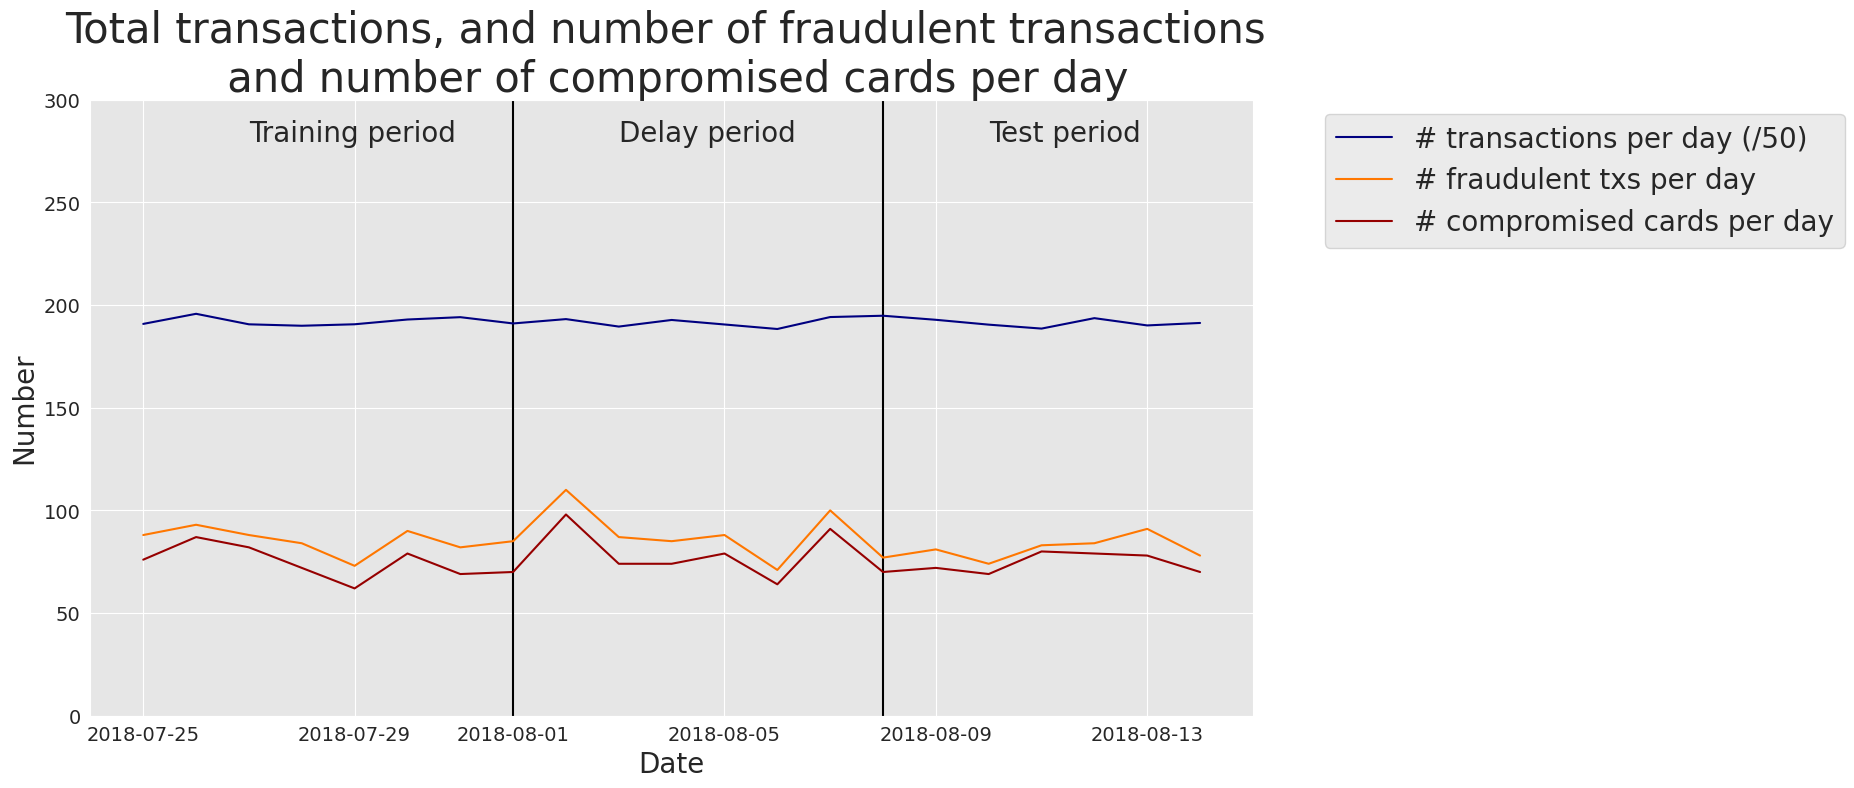

In [9]:
fraud_and_transactions_stats_fig

In [10]:
def get_train_test_set(transactions_df,
                       start_date_training,
                       delta_train=7,delta_delay=7,delta_test=7):

    # Get the training set data
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]

    # Get the test set data
    test_df = []

    # Note: Cards known to be compromised after the delay period are removed from the test set
    # That is, for each test day, all frauds known at (test_day-delay_period) are removed

    # First, get known defrauded customers from the training set
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)

    # Get the relative starting day of training set (easier than TX_DATETIME to collect test data)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()

    # Then, for each day of the test set
    for day in range(delta_test):

        # Get test data for that day
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]

        # Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]

        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)

        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]

        test_df.append(test_df_day)

    test_df = pd.concat(test_df)

    # Sort data sets by ascending order of transaction ID
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')

    return (train_df, test_df)

In [11]:
(train_df, test_df)=get_train_test_set(transactions_df,start_date_training,
                                       delta_train=7,delta_delay=7,delta_test=7)

Tập train gồm có 67240 giao dịch, trong đó có 598 giao dịch là gian lận.

In [12]:
train_df.shape

(67240, 23)

In [13]:
train_df[train_df.TX_FRAUD==1].shape

(598, 23)

Tập test gồm có 58264 giao dịch, trong đó có 385 giao dịch là gian lận.

In [14]:
test_df.shape

(58264, 23)

In [15]:
test_df[test_df.TX_FRAUD==1].shape

(385, 23)

Tức là, tỷ lệ giao dịch gian lận là 0,007.

In [16]:
385/58264

0.00660785390635727

# <font color = "FF6666">2. Model training : Decision tree</font>

In [ ]:
output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']

In [ ]:
def fit_model_and_get_predictions(classifier, train_df, test_df,
                                  input_features, output_feature="TX_FRAUD",scale=True):

    # By default, scales input data
    if scale:
        (train_df, test_df)=scaleData(train_df,test_df,input_features)

    # We first train the classifier using the `fit` method, and pass as arguments the input and output features
    start_time=time.time()
    classifier.fit(train_df[input_features], train_df[output_feature])
    training_execution_time=time.time()-start_time

    # We then get the predictions on the training and test data using the `predict_proba` method
    # The predictions are returned as a numpy array, that provides the probability of fraud for each transaction
    start_time=time.time()
    predictions_test=classifier.predict_proba(test_df[input_features])[:,1]
    prediction_execution_time=time.time()-start_time

    predictions_train=classifier.predict_proba(train_df[input_features])[:,1]

    # The result is returned as a dictionary containing the fitted models,
    # and the predictions on the training and test sets
    model_and_predictions_dictionary = {'classifier': classifier,
                                        'predictions_test': predictions_test,
                                        'predictions_train': predictions_train,
                                        'training_execution_time': training_execution_time,
                                        'prediction_execution_time': prediction_execution_time
                                       }

    return model_and_predictions_dictionary

In [ ]:
# We first create a decision tree object. We will limit its depth to 2 for interpretability,
# and set the random state to zero for reproducibility
classifier = sklearn.tree.DecisionTreeClassifier(max_depth = 2, random_state=0)

model_and_predictions_dictionary = fit_model_and_get_predictions(classifier, train_df, test_df,
                                                                 input_features, output_feature,
                                                                 scale=False)

In [ ]:
test_df['TX_FRAUD_PREDICTED']=model_and_predictions_dictionary['predictions_test']
test_df.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW,TX_FRAUD_PREDICTED
134215,1236698,2018-08-08 00:01:14,2765,2747,42.32,11145674,129,0,0,0,...,67.468529,120.0,64.611750,2.0,0.0,9.0,0.0,31.0,0.000000,0.003536
134216,1236699,2018-08-08 00:02:33,714,2073,108.19,11145753,129,0,0,0,...,79.955455,124.0,85.365645,2.0,0.0,10.0,0.0,23.0,0.000000,0.003536
134218,1236701,2018-08-08 00:08:40,4982,1258,26.13,11146120,129,0,0,0,...,56.269167,61.0,49.095902,1.0,0.0,10.0,0.0,26.0,0.076923,0.003536
134219,1236702,2018-08-08 00:08:41,704,8501,65.81,11146121,129,0,0,0,...,62.643333,11.0,63.287273,1.0,0.0,6.0,0.0,23.0,0.000000,0.003536
134220,1236703,2018-08-08 00:10:34,3085,4208,55.22,11146234,129,0,0,0,...,71.993846,72.0,59.899306,1.0,0.0,5.0,0.0,21.0,0.523810,0.003536


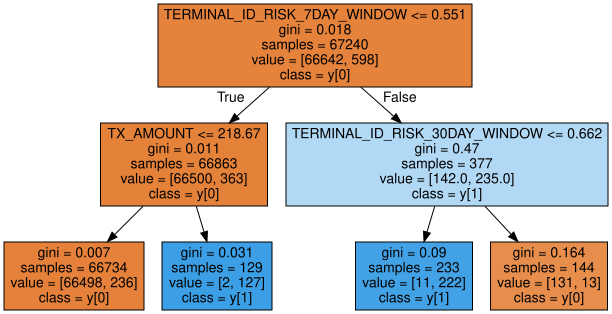

In [ ]:
display(graphviz.Source(sklearn.tree.export_graphviz(classifier,feature_names=input_features,class_names=True, filled=True)))

# <font color = "FF6666">3. Đánh giá hiệu suất</font>

In [ ]:
def card_precision_top_k_day(df_day,top_k):

    # This takes the max of the predictions AND the max of label TX_FRAUD for each CUSTOMER_ID,
    # and sorts by decreasing order of fraudulent prediction
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)

    # Get the top k most suspicious cards
    df_day_top_k=df_day.head(top_k)
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)

    # Compute precision top k
    card_precision_top_k = len(list_detected_compromised_cards) / top_k

    return list_detected_compromised_cards, card_precision_top_k

def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):

    # Sort days by increasing order
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()

    # At first, the list of detected compromised cards is empty
    list_detected_compromised_cards = []

    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []

    # For each day, compute precision top k
    for day in list_days:

        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]

        # Let us remove detected compromised cards from the set of daily transactions
        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]

        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))

        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)

        card_precision_top_k_per_day_list.append(card_precision_top_k)

        # Let us update the list of detected compromised cards
        if remove_detected_compromised_cards:
            list_detected_compromised_cards.extend(detected_compromised_cards)

    # Compute the mean
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()

    # Returns precision top k per day as a list, and resulting mean
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k

def performance_assessment(predictions_df, output_feature='TX_FRAUD',
                           prediction_feature='predictions', top_k_list=[100],
                           rounded=True):

    AUC_ROC = metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])
    AP = metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])

    performances = pd.DataFrame([[AUC_ROC, AP]],
                           columns=['AUC ROC','Average precision'])

    for top_k in top_k_list:

        _, _, mean_card_precision_top_k = card_precision_top_k(predictions_df, top_k)
        performances['Card Precision@'+str(top_k)]=mean_card_precision_top_k

    if rounded:
        performances = performances.round(3)

    return performances

In [ ]:
predictions_df=test_df
predictions_df['predictions']=model_and_predictions_dictionary['predictions_test']

performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.763,0.496,0.241


Chỉ số dễ hiểu nhất là Card Precision@100, cho biết mỗi ngày, 24% số thẻ có điểm gian lận cao nhất thực sự bị xâm phạm.

có nghĩa là trung bình, bộ phân loại này cho phép phát hiện chính xác 24 thẻ bị xâm phạm mỗi ngày trong số 100 thẻ đáng ngờ nhất được xác định bởi mô hình dự đoán.

In [ ]:
predictions_df['predictions']=0.5

performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.5,0.007,0.016


# <font color = "FF6666">4. Hiệu suất sử dụng các mô hình dự đoán tiêu chuẩn</font>

In [ ]:
classifiers_dictionary={'Logistic regression':sklearn.linear_model.LogisticRegression(random_state=0),
                        'Decision tree with depth of two':sklearn.tree.DecisionTreeClassifier(max_depth=2,random_state=0),
                        'Decision tree - unlimited depth':sklearn.tree.DecisionTreeClassifier(random_state=0),
                        'Random forest':sklearn.ensemble.RandomForestClassifier(random_state=0,n_jobs=-1),
                        'XGBoost':xgboost.XGBClassifier(random_state=0,n_jobs=-1),
                       }

fitted_models_and_predictions_dictionary={}

for classifier_name in classifiers_dictionary:

    model_and_predictions = fit_model_and_get_predictions(classifiers_dictionary[classifier_name], train_df, test_df,
                                                                                  input_features=input_features,
                                                                                output_feature=output_feature)
    fitted_models_and_predictions_dictionary[classifier_name]=model_and_predictions

In [ ]:
def performance_assessment_model_collection(fitted_models_and_predictions_dictionary,
                                            transactions_df,
                                            type_set='test',
                                            top_k_list=[100]):

    performances=pd.DataFrame()

    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():

        predictions_df=transactions_df

        predictions_df['predictions']=model_and_predictions['predictions_'+type_set]

        performances_model=performance_assessment(predictions_df, output_feature='TX_FRAUD',
                                                   prediction_feature='predictions', top_k_list=top_k_list)
        performances_model.index=[classifier_name]

        performances=pd.concat([performances, performances_model])

    return performances

In [ ]:
# performances on test set
df_performances=performance_assessment_model_collection(fitted_models_and_predictions_dictionary, test_df,
                                                        type_set='test',
                                                        top_k_list=[100])
df_performances

,AUC ROC,Average precision,Card Precision@100
Logistic regression,0.870,0.605,0.291
Decision tree with depth of two,0.763,0.496,0.241
Decision tree - unlimited depth,0.788,0.309,0.241
Random forest,0.867,0.658,0.287
XGBoost,0.851,0.572,0.257


In [ ]:
# performances on training set
df_performances=performance_assessment_model_collection(fitted_models_and_predictions_dictionary, train_df,
                                                        type_set='train',
                                                        top_k_list=[100])
df_performances

,AUC ROC,Average precision,Card Precision@100
Logistic regression,0.892,0.663,0.419
Decision tree with depth of two,0.802,0.586,0.393
Decision tree - unlimited depth,1.000,1.000,0.576
Random forest,1.000,1.000,0.576
XGBoost,1.000,0.991,0.574


Các mô hình ít nhạy cảm nhất với hiện tượng quá khớp là mô hình hồi quy logistic và cây quyết định với độ sâu 2.

In [ ]:
def execution_times_model_collection(fitted_models_and_predictions_dictionary):

    execution_times=pd.DataFrame()

    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():

        execution_times_model=pd.DataFrame()
        execution_times_model['Training execution time']=[model_and_predictions['training_execution_time']]
        execution_times_model['Prediction execution time']=[model_and_predictions['prediction_execution_time']]
        execution_times_model.index=[classifier_name]

        execution_times=pd.concat([execution_times, execution_times_model])

    return execution_times

In [ ]:
# Execution times
df_execution_times=execution_times_model_collection(fitted_models_and_predictions_dictionary)
df_execution_times

,Training execution time,Prediction execution time
Logistic regression,0.425041,0.015513
Decision tree with depth of two,0.174285,0.008993
Decision tree - unlimited depth,1.622683,0.014817
Random forest,17.506505,0.504596
XGBoost,0.831816,0.122518


# <font color = "FF6666">5. Các matric đánh giá hiệu suất</font>

Các chỉ số phổ biến nhất là the recall, the specificity, the precision, the F1 score, the AUC ROC, và the Average Precision.

### <font color = "green">5.1 Threshold-based metrics</font>



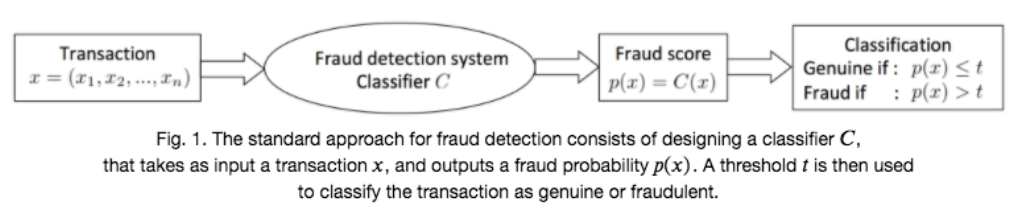

nguồn : https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_4_PerformanceMetrics/ThresholdBased.html

In [ ]:
!pip install pretty-confusion-matrix

In [ ]:
from pretty_confusion_matrix import pp_matrix_from_data

In [ ]:
# Getting classes from a vector of fraud probabilities and a threshold
def get_class_from_fraud_probability(fraud_probabilities, threshold=0.5):

    predicted_classes = [0 if fraud_probability<threshold else 1
                         for fraud_probability in fraud_probabilities]

    return predicted_classes

In [ ]:
# Implementation of the mean misclassification error
def compute_MME(true_labels,predicted_classes):

    N = len(true_labels)

    MME = np.sum(np.array(true_labels)!=np.array(predicted_classes))/N

    return MME

Chỉ số MME thường là một chỉ báo tốt về hiệu suất của bộ phân loại đối với các tập dữ liệu cân bằng.

Đối với các vấn đề nhạy cảm về chi phí như phát hiện gian lận, MME có một số hạn chế.

In [ ]:
# 2 fraudulent and 8 genuine transactions
true_labels = [1,1,0,0,0,0,0,0,0,0]

# Probability of fraud for each transaction
fraud_probabilities = [0.9,0.35,0.45,0.4,0.2,0.2,0.2,0.1,0.1,0]

Threshold = 1
MME = 0.2000


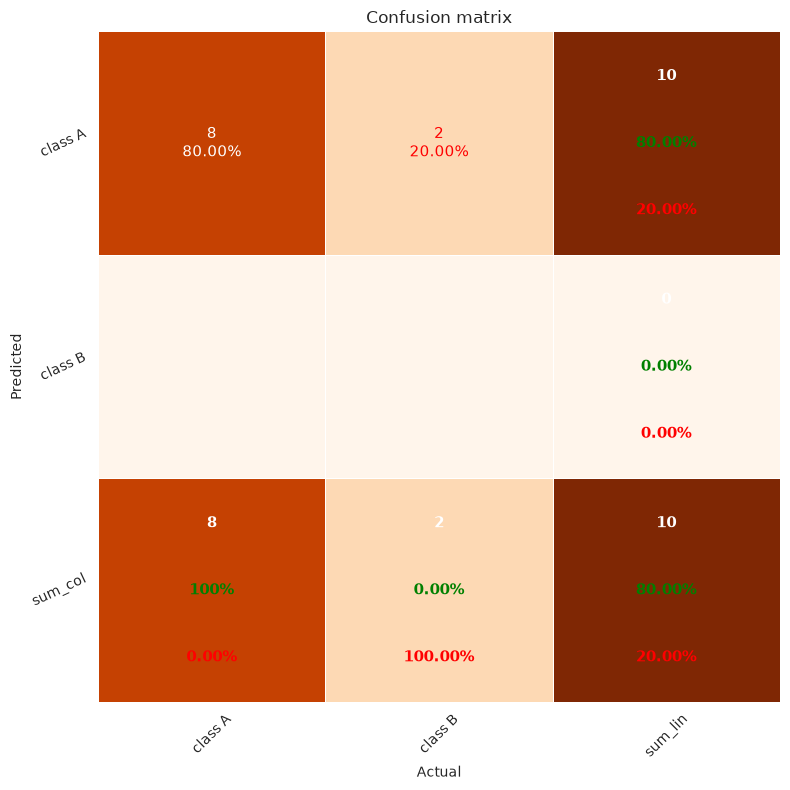

Threshold = 0.5
MME = 0.1000


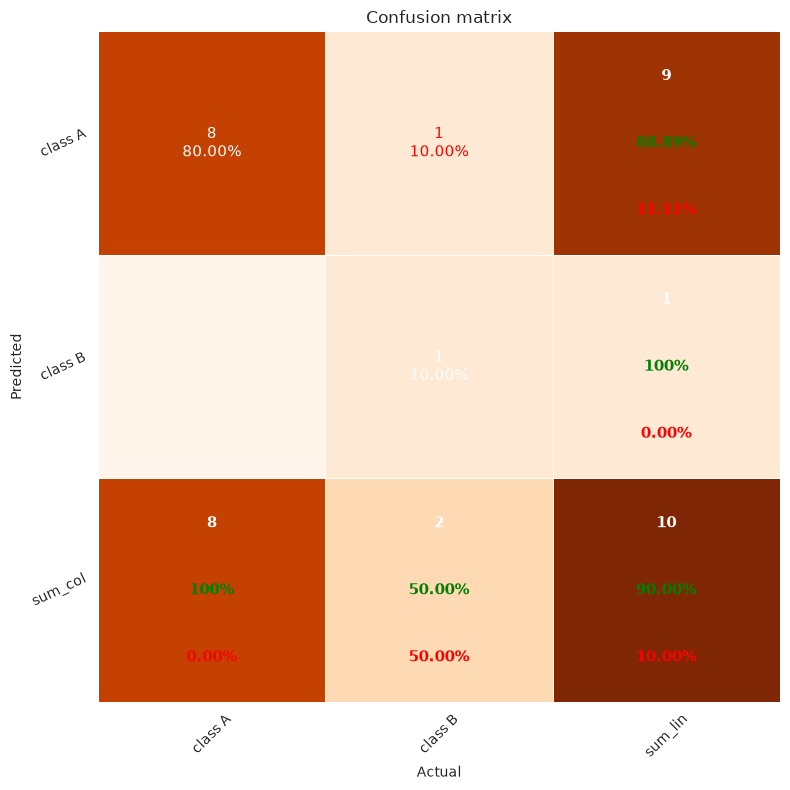

Threshold = 0.3
MME = 0.2000


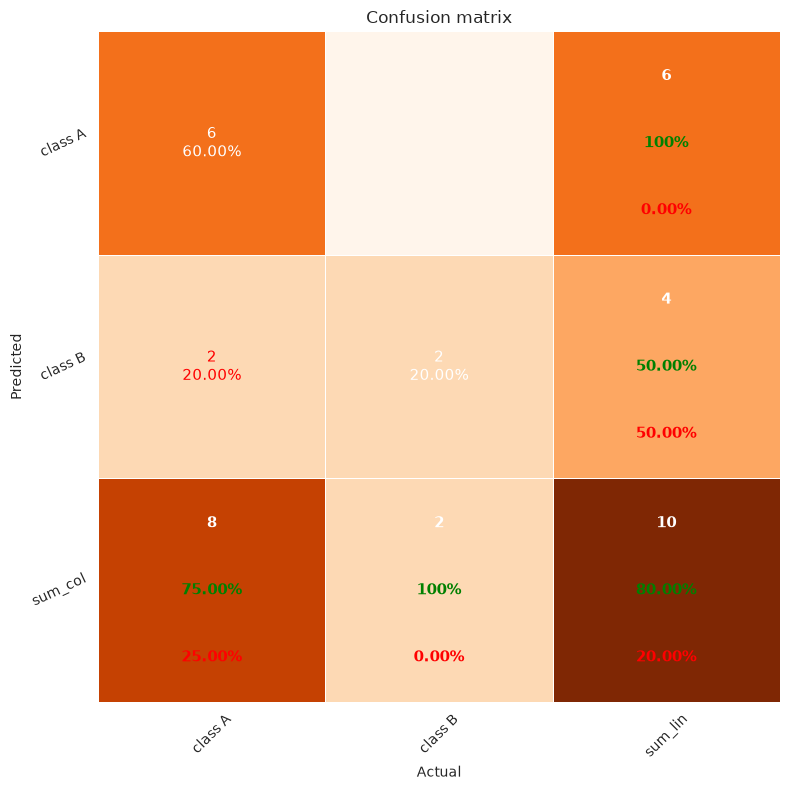

In [ ]:
thresholds = [1, 0.5, 0.3]

for threshold in thresholds:

    predicted_classes = get_class_from_fraud_probability(
        fraud_probabilities,
        threshold=threshold
    )

    mme = compute_MME(true_labels, predicted_classes)

    print("=" * 50)
    print(f"Threshold = {threshold}")
    print(f"MME = {mme:.4f}")

    pp_matrix_from_data(true_labels, predicted_classes)

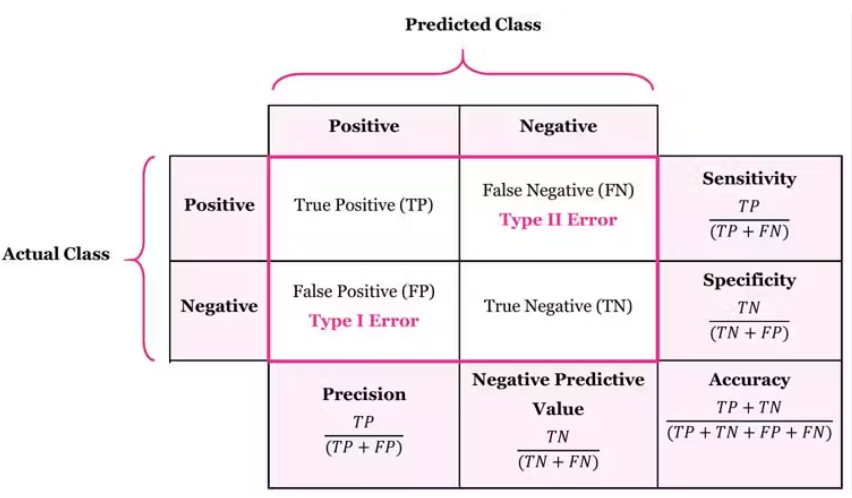


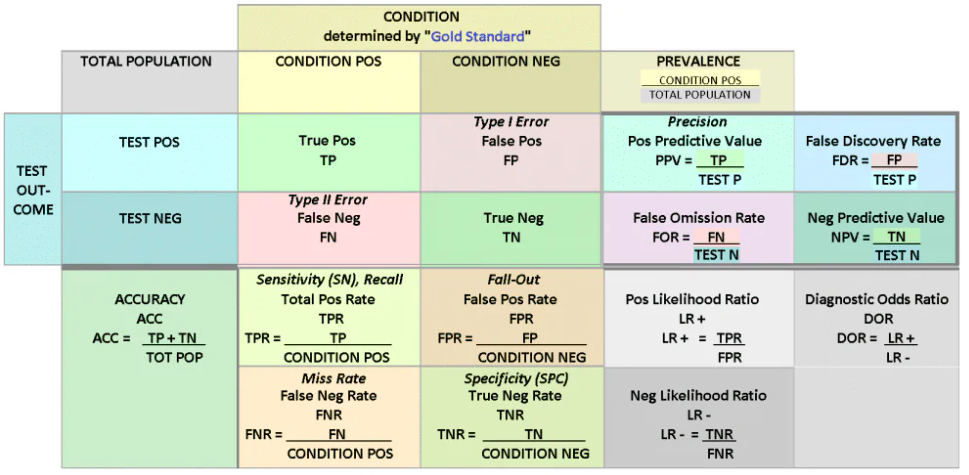

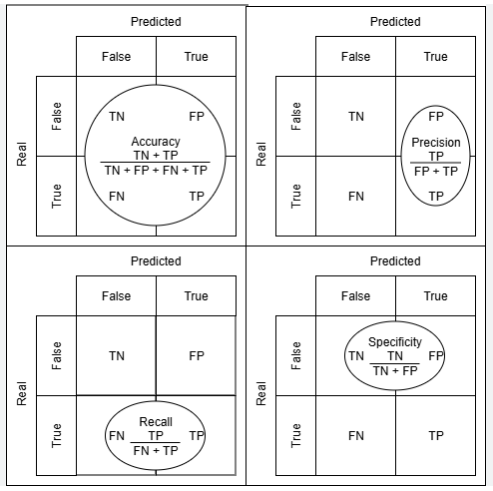

In [ ]:
def threshold_based_metrics(fraud_probabilities, true_label, thresholds_list):

    results = []

    for threshold in thresholds_list:

        predicted_classes = get_class_from_fraud_probability(fraud_probabilities, threshold=threshold)

        (TN, FP, FN, TP) = metrics.confusion_matrix(true_label, predicted_classes).ravel()

        MME = (FP+FN)/(TN+FP+FN+TP)

        TPR = TP/(TP+FN)
        TNR = TN/(TN+FP)

        FPR = FP/(TN+FP)
        FNR = FN/(TP+FN)

        BER = 1/2*(FPR+FNR)

        Gmean = np.sqrt(TPR*TNR)

        precision = 0
        FDR = 0
        F1_score=0

        if TP+FP>0:
            precision = TP/(TP+FP)
            FDR=FP/(TP+FP)

        NPV = 0
        FOR = 0

        if TN+FN>0:
            NPV = TN/(TN+FN)
            FOR = FN/(TN+FN)


        if precision+TPR>0:
            F1_score = 2*(precision*TPR)/(precision+TPR)

        results.append([threshold, MME, TPR, TNR, FPR, FNR, BER, Gmean, precision, NPV, FDR, FOR, F1_score])

    results_df = pd.DataFrame(results,columns=['Threshold' ,'MME', 'TPR', 'TNR', 'FPR', 'FNR', 'BER', 'G-mean', 'Precision', 'NPV', 'FDR', 'FOR', 'F1 Score'])

    return results_df

In [ ]:
unique_thresholds = list(set(fraud_probabilities))
unique_thresholds.sort(reverse=True)
unique_thresholds

[0.9, 0.45, 0.4, 0.35, 0.2, 0.1, 0]

In [ ]:
results_df = threshold_based_metrics(fraud_probabilities, true_labels, unique_thresholds)

In [ ]:
results_df

,Threshold,MME,TPR,TNR,FPR,FNR,BER,G-mean,Precision,NPV,FDR,FOR,F1 Score
0,0.90,0.1,0.5,1.000,0.000,0.5,0.2500,0.707107,1.000000,0.888889,0.000000,0.111111,0.666667
1,0.45,0.2,0.5,0.875,0.125,0.5,0.3125,0.661438,0.500000,0.875000,0.500000,0.125000,0.500000
2,0.40,0.3,0.5,0.750,0.250,0.5,0.3750,0.612372,0.333333,0.857143,0.666667,0.142857,0.400000
3,0.35,0.2,1.0,0.750,0.250,0.0,0.1250,0.866025,0.500000,1.000000,0.500000,0.000000,0.666667
4,0.20,0.5,1.0,0.375,0.625,0.0,0.3125,0.612372,0.285714,1.000000,0.714286,0.000000,0.444444
5,0.10,0.7,1.0,0.125,0.875,0.0,0.4375,0.353553,0.222222,1.000000,0.777778,0.000000,0.363636
6,0.00,0.8,1.0,0.000,1.000,0.0,0.5000,0.000000,0.200000,0.000000,0.800000,0.000000,0.333333


### <font color = "green">5.2 Threshold-free metrics</font>



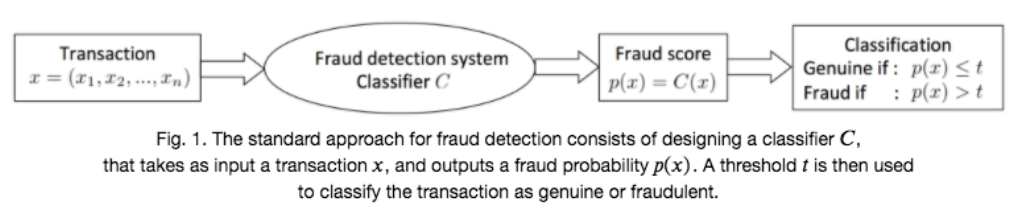

In [ ]:
# Initialization: Load shared functions and simulated data

# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 63257  100 63257    0     0   270k      0 --:--:-- --:--:-- --:--:--  272k


<Figure size 640x480 with 0 Axes>

In [ ]:
# 2 fraudulent and 8 genuine transactions
true_labels = [1,1,0,0,0,0,0,0,0,0]

# Probability of fraud for each transaction
fraud_probabilities = [0.9,0.35,0.45,0.4,0.2,0.2,0.2,0.1,0.1,0]

Một ngưỡng cao hơn 1 (được đặt là 1.1) cũng được thêm vào cho trường hợp tất cả các giao dịch đều được dự đoán là hợp lệ.

In [ ]:
unique_thresholds = [1.1]+list(set(fraud_probabilities))
unique_thresholds.sort(reverse=True)
unique_thresholds

[1.1, 0.9, 0.45, 0.4, 0.35, 0.2, 0.1, 0]

In [ ]:
performance_metrics=threshold_based_metrics(fraud_probabilities, true_labels, unique_thresholds)
performance_metrics[['Threshold','TPR','FPR']]

,Threshold,TPR,FPR
0,1.10,0.0,0.000
1,0.90,0.5,0.000
2,0.45,0.5,0.125
3,0.40,0.5,0.250
4,0.35,1.0,0.250
5,0.20,1.0,0.625
6,0.10,1.0,0.875
7,0.00,1.0,1.000


Đúng như dự đoán, ngưỡng càng thấp thì tỷ lệ phát hiện giao dịch đúng (TPR) càng cao (càng phát hiện nhiều giao dịch gian lận), nhưng tỷ lệ phát hiện giao dịch sai (FPR) cũng càng cao (càng nhiều giao dịch hợp lệ bị phân loại là gian lận).

In [ ]:
FPR_list, TPR_list, threshold = sklearn.metrics.roc_curve(true_labels, fraud_probabilities, drop_intermediate=False)
FPR_list, TPR_list, threshold

(array([0.   , 0.   , 0.125, 0.25 , 0.25 , 0.625, 0.875, 1.   ]),
 array([0. , 0.5, 0.5, 0.5, 1. , 1. , 1. , 1. ]),
 array([ inf, 0.9 , 0.45, 0.4 , 0.35, 0.2 , 0.1 , 0.  ]))

In [ ]:
%%capture
def get_template_roc_curve(ax, title,fs,random=True):

    ax.set_title(title, fontsize=fs)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])

    ax.set_xlabel('False Positive Rate', fontsize=fs)
    ax.set_ylabel('True Positive Rate', fontsize=fs)

    if random:
        ax.plot([0, 1], [0, 1],'r--',label="AUC ROC Random = 0.5")

ROC_AUC = metrics.auc(FPR_list, TPR_list)

roc_curve, ax = plt.subplots(figsize=(5,5))
get_template_roc_curve(ax, "Receiver Operating Characteristic (ROC) Curve",fs=15)
ax.plot(FPR_list, TPR_list, 'b', color='blue', label = 'AUC ROC Classifier = {0:0.3f}'.format(ROC_AUC))
ax.legend(loc = 'lower right')

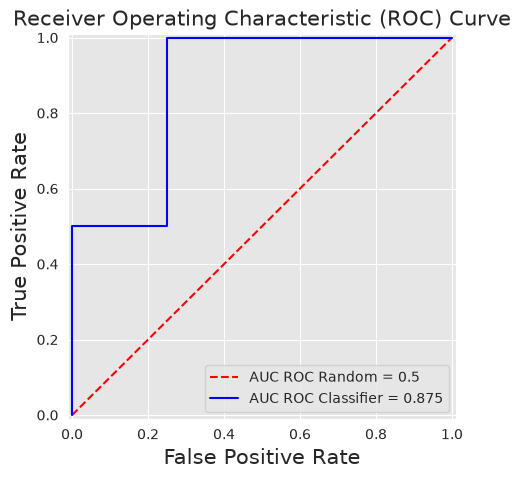

In [ ]:
roc_curve

In [17]:
output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']

classifiers_dictionary={'Logistic regression':sklearn.linear_model.LogisticRegression(random_state=0),
                        'Decision tree with depth of two':sklearn.tree.DecisionTreeClassifier(max_depth=2,random_state=0),
                        'Decision tree - unlimited depth':sklearn.tree.DecisionTreeClassifier(random_state=0),
                        'Random forest':sklearn.ensemble.RandomForestClassifier(random_state=0,n_jobs=-1),
                        'XGBoost':xgboost.XGBClassifier(random_state=0,n_jobs=-1),
                       }

fitted_models_and_predictions_dictionary={}

for classifier_name in classifiers_dictionary:

    start_time=time.time()
    model_and_predictions = fit_model_and_get_predictions(classifiers_dictionary[classifier_name], train_df, test_df,
                                                          input_features=input_features,
                                                          output_feature=output_feature)

    print("Time to fit the "+classifier_name+" model: "+str(round(time.time()-start_time,2)))

    fitted_models_and_predictions_dictionary[classifier_name]=model_and_predictions


Time to fit the Logistic regression model: 0.43
Time to fit the Decision tree with depth of two model: 0.42
Time to fit the Decision tree - unlimited depth model: 2.46
Time to fit the Random forest model: 23.13
Time to fit the XGBoost model: 3.85


In [18]:
%%capture
roc_curve, ax = plt.subplots(1, 1, figsize=(5,5))

cmap = plt.get_cmap('jet')
colors={'Logistic regression':cmap(0), 'Decision tree with depth of two':cmap(200),
        'Decision tree - unlimited depth':cmap(250),
        'Random forest':cmap(70), 'XGBoost':cmap(40)}

get_template_roc_curve(ax,title='Receiver Operating Characteristic Curve\nTest data',fs=15)

for classifier_name in classifiers_dictionary:

    model_and_predictions=fitted_models_and_predictions_dictionary[classifier_name]

    FPR_list, TPR_list, threshold = metrics.roc_curve(test_df[output_feature], model_and_predictions['predictions_test'])
    ROC_AUC = metrics.auc(FPR_list, TPR_list)

    ax.plot(FPR_list, TPR_list, 'b', color=colors[classifier_name], label = 'AUC ROC {0}= {1:0.3f}'.format(classifier_name,ROC_AUC))
    ax.legend(loc = 'upper left',bbox_to_anchor=(1.05, 1))

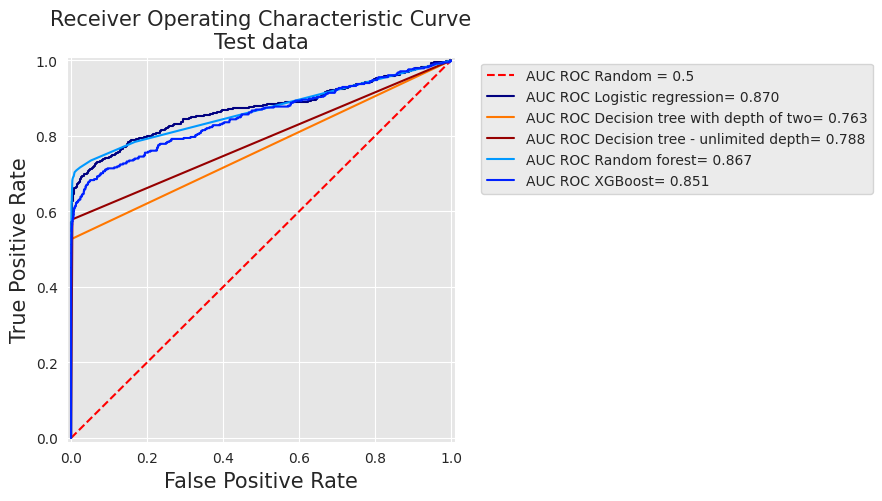

In [19]:
roc_curve